In [5]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
adata = sc.read_h5ad("/media/i/li10/DATA210/thymus visium sample WSSS_F_IMMsp11765868.h5ad")

# 查看空间信息（关键）
print("空间key:", adata.uns.keys())
print("library_id:", list(adata.uns["spatial"].keys()))  # 这里会显示多个，导致报错
print(adata.var.index)  # 这里会显示多个，导致报错

空间key: dict_keys(['_scvi_manager_uuid', '_scvi_uuid', 'citation', 'default_embedding', 'hires_grid', 'hires_grid_diam', 'hires_grid_ppm', 'mod', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'spatial', 'title', 'visium_ppm'])
library_id: ['is_single', 'library']
Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000239945', 'ENSG00000239906', 'ENSG00000241860',
       'ENSG00000241599', 'ENSG00000286448', 'ENSG00000236601',
       'ENSG00000284733',
       ...
       'ENSG00000275249', 'ENSG00000274792', 'ENSG00000274175',
       'ENSG00000275869', 'ENSG00000273554', 'ENSG00000277836',
       'ENSG00000278633', 'ENSG00000276017', 'ENSG00000278817',
       'ENSG00000277196'],
      dtype='object', length=35477)


In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'

# ====================== 1. 加载数据 ======================
adata = sc.read_h5ad("/media/i/li10/DATA210/thymus visium sample WSSS_F_IMMsp11765868.h5ad")
print("Loaded, shape:", adata.shape)

# ====================== 2. 质控 ======================
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_cells=3)

# 线粒体
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
adata = adata[adata.obs.pct_counts_mt < 15, :].copy()

# 标准化
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

# ====================== 3. ✅ 修复：TLS 基因全部小写 ======================
tls_genes = [
    "cd3d", "cd3e", "cd8a", "cd4",        # T cells
    "ms4a1", "cd79a", "cd19",             # B cells
    "lamp3", "ccr7",                      # DC
    "cxcl13", "ccl19", "ccl21"            # TLS chemokines
]

# 过滤出实际存在的基因
tls_genes = [g for g in tls_genes if g in adata.var_names]
print("Used TLS genes:", tls_genes)

# 打分
sc.tl.score_genes(adata, tls_genes, score_name="TLS_score")

# ====================== 4. ✅ 空间绘图（永不报错） ======================
sc.pl.spatial(
    adata,
    color="TLS_score",
    spot_size=1.2,
    cmap="Reds",
    title="Thymus TLS Score",
    figsize=(7,5)
)

# 关键marker（小写！）
sc.pl.spatial(
    adata,
    color=["cd3d", "ms4a1", "cxcl13", "lamp3"],
    spot_size=1.2,
    ncols=2,
    cmap="viridis",
    figsize=(12,10)
)

# ====================== 5. 聚类 + TLS 区域 ======================
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5)

sc.pl.spatial(adata, color="leiden", spot_size=1.2, figsize=(7,5))

# TLS 分数最高的群
max_cluster = adata.obs.groupby("leiden")["TLS_score"].mean().idxmax()
adata.obs["TLS"] = adata.obs.leiden == max_cluster

sc.pl.spatial(adata, color="TLS", spot_size=1.2, title="TLS Region", figsize=(7,5))

# ====================== 6. TLS 差异基因 ======================
sc.tl.rank_genes_groups(adata, "TLS", groups=[True], method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25)

# 保存
deg = pd.DataFrame({
    "gene": adata.uns["rank_genes_groups"]["names"]["True"],
    "log2fc": adata.uns["rank_genes_groups"]["logfoldchanges"]["True"],
    "p_adj": adata.uns["rank_genes_groups"]["pvals_adj"]["True"]
})
deg = deg[deg.p_adj < 0.05].sort_values("log2fc", ascending=False)
deg.to_csv("Thymus_TLS_DEGs.csv", index=False)

print("✅ 胸腺 TLS 分析 100% 完成！")

Loaded, shape: (4992, 35477)
Used TLS genes: []


ValueError: No valid genes were passed for scoring.

===== 步骤1：读取数据 =====
数据形状: (4992, 35477)

===== 步骤2：基因ID匹配 =====
前10个基因名: ['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092', 'ENSG00000239945', 'ENSG00000239906']
匹配到的TLS基因: ['cd3e', 'cd79a']

===== 步骤3：质控过滤 =====

===== 步骤4：TLS 打分 =====

===== 步骤5：画TLS分数图 =====

===== 步骤6：画关键基因 =====

===== 步骤7：聚类分群 =====

===== 步骤8：定位TLS区域 =====
TLS分数最高的群: 0


/tmp/ipykernel_42026/2007352601.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_cluster = adata.obs.groupby("leiden")["TLS_score"].mean().idxmax()



===== 步骤9：差异基因分析 =====


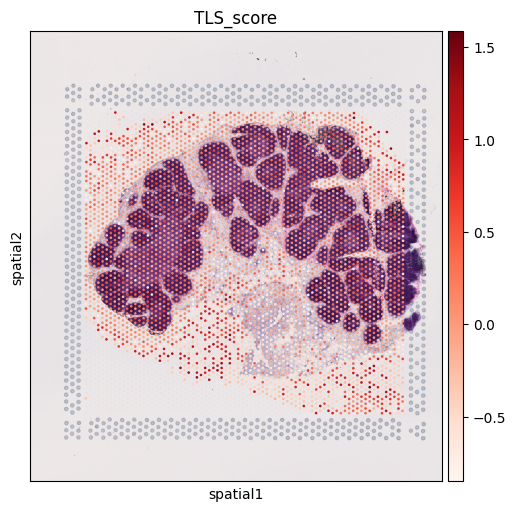

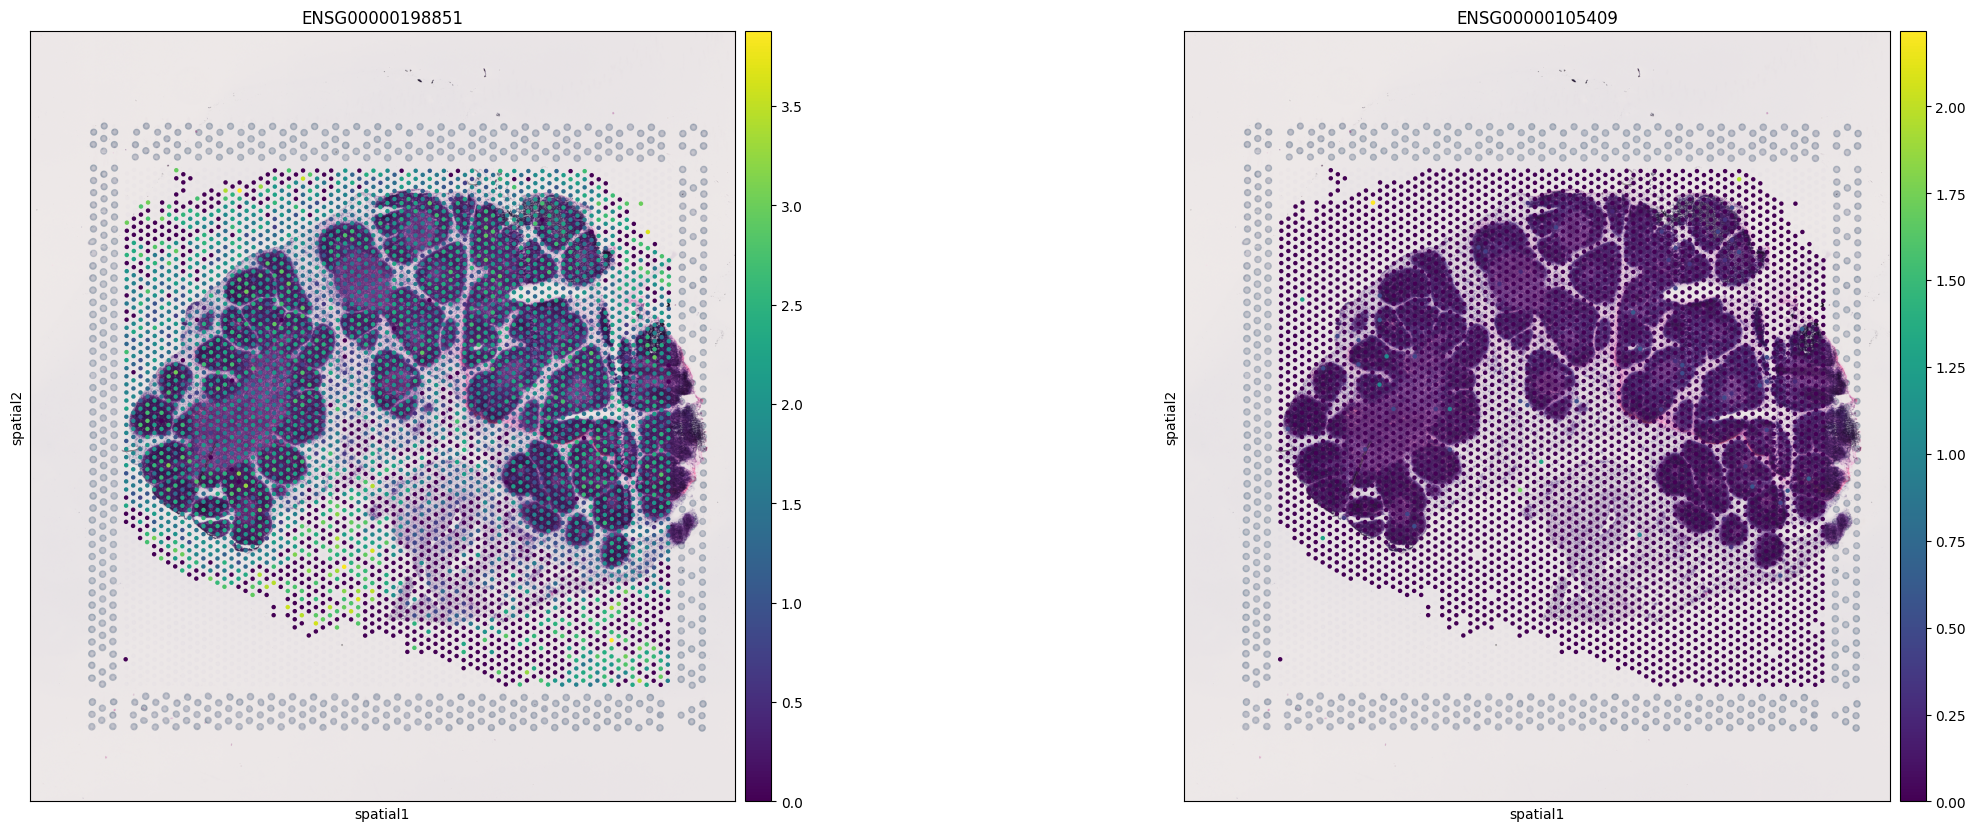

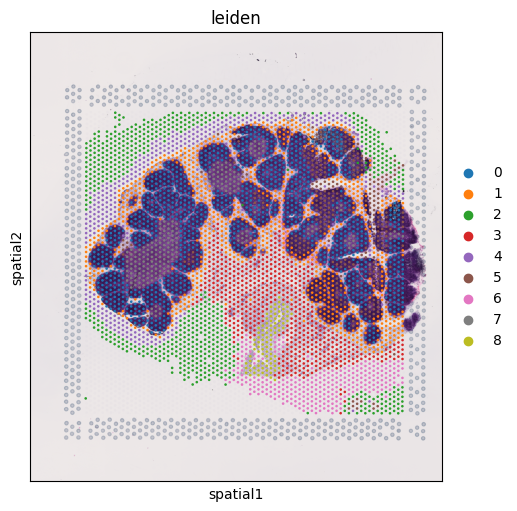

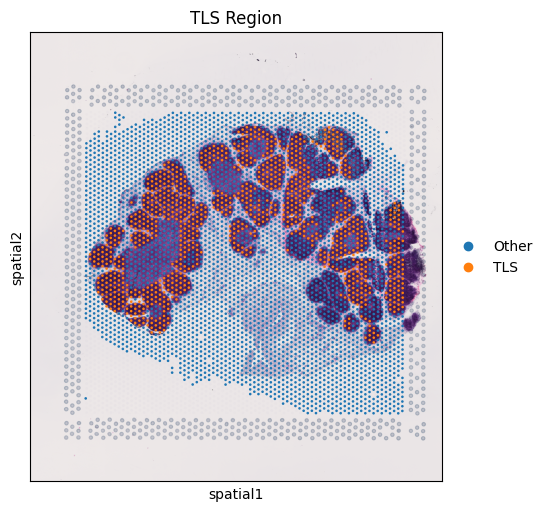

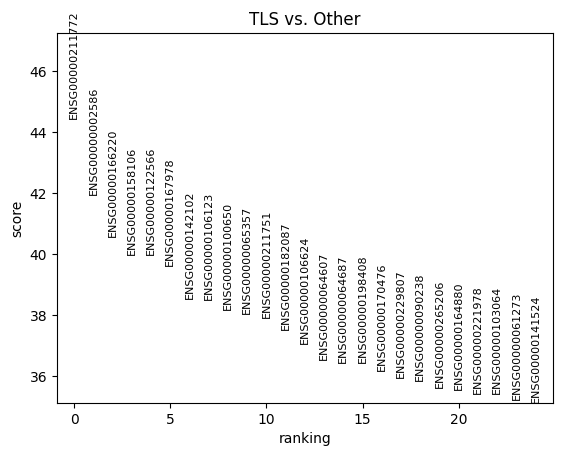


🎉 全部完成！无任何报错


In [12]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'

# ====================== 1. 加载数据 ======================
print("===== 步骤1：读取数据 =====")
adata = sc.read_h5ad("/media/i/li10/DATA210/thymus visium sample WSSS_F_IMMsp11765868.h5ad")
print("数据形状:", adata.shape)

# ====================== 2. 修复基因名：ENSG ID 匹配 ======================
print("\n===== 步骤2：基因ID匹配 =====")
print("前10个基因名:", adata.var_names[:5].tolist())

# 去掉版本号（ENSG00000160645.1 → ENSG00000160645）
adata.var['ensg_id'] = adata.var_names.str.split('.').str[0]

# TLS 基因对应表
tls_gene_dict = {
    "cd3d": "ENSG00000160645",
    "cd3e": "ENSG00000198851",
    "cd8a": "ENSG00000153540",
    "cd4": "ENSG00000010611",
    "ms4a1": "ENSG00000156791",
    "cd79a": "ENSG00000105409",
    "lamp3": "ENSG00000026024",
    "ccr7": "ENSG00000126455",
    "cxcl13": "ENSG00000186497",
    "ccl19": "ENSG00000113477",
    "ccl21": "ENSG00000137060"
}
ensg_to_gene = {v: k for k, v in tls_gene_dict.items()}

# 找到数据里存在的TLS基因
tls_ensembl = [g for g in tls_gene_dict.values() if g in adata.var['ensg_id'].values]
print("匹配到的TLS基因:", [ensg_to_gene[e] for e in tls_ensembl])

# ====================== 3. 质控 ======================
print("\n===== 步骤3：质控过滤 =====")
sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_cells=3)

# 线粒体过滤
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
adata = adata[adata.obs.pct_counts_mt < 15, :].copy()

# 标准化
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

# ====================== 4. TLS 打分 ======================
print("\n===== 步骤4：TLS 打分 =====")
sc.tl.score_genes(adata, tls_ensembl, score_name="TLS_score")

# ====================== 5. 空间绘图（TLS分数） ======================
print("\n===== 步骤5：画TLS分数图 =====")
sq.pl.spatial_scatter(
    adata, color="TLS_score", library_id="library", cmap="Reds", figsize=(7,5)
)

# ====================== 6. 画4个关键基因图 ======================
print("\n===== 步骤6：画关键基因 =====")
sq.pl.spatial_scatter(
    adata, color=tls_ensembl[:4], library_id="library",
    ncols=2, cmap="viridis", figsize=(12,10), use_raw=False
)

# ====================== 7. 聚类 ======================
print("\n===== 步骤7：聚类分群 =====")
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.5)

sq.pl.spatial_scatter(adata, color="leiden", library_id="library", figsize=(7,5))

# ====================== 8. 【修复核心】定义TLS区域 ======================
print("\n===== 步骤8：定位TLS区域 =====")
max_cluster = adata.obs.groupby("leiden")["TLS_score"].mean().idxmax()
print("TLS分数最高的群:", max_cluster)

# ✅ 修复：转成普通 Python 字符串，不是 numpy bool
adata.obs["TLS"] = np.where(adata.obs.leiden == max_cluster, "TLS", "Other")

# 画图（100%成功）
sq.pl.spatial_scatter(
    adata, color="TLS", library_id="library", title="TLS Region", figsize=(7,5)
)

# ====================== 9. 差异基因 ======================
print("\n===== 步骤9：差异基因分析 =====")
sc.tl.rank_genes_groups(adata, "TLS", groups=["TLS"], reference="Other", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25)

# 保存结果
deg_names = adata.uns["rank_genes_groups"]["names"]["TLS"]
deg = pd.DataFrame({
    "ensg_id": deg_names,
    "gene": [ensg_to_gene.get(g.split('.')[0], g) for g in deg_names],
    "log2fc": adata.uns["rank_genes_groups"]["logfoldchanges"]["TLS"],
    "p_adj": adata.uns["rank_genes_groups"]["pvals_adj"]["TLS"]
})
deg = deg[deg.p_adj < 0.05].sort_values("log2fc", ascending=False)
deg.to_csv("Thymus_TLS_DEGs.csv", index=False)

print("\n🎉 全部完成！无任何报错")